In [60]:
from dotenv import load_dotenv
load_dotenv()

True

In [61]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph ,START,END
from pydantic import BaseModel,Field
from typing import Literal
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain.agents import create_agent

from langchain.tools import tool


In [62]:
class FlowState(BaseModel):
    question:str=Field(description="User asked question")
    category:Literal['coding','google_search','weather']=Field(default='google_search')
    answer:str=Field(default="")
    

In [63]:
class QuestionCategory(BaseModel):
    category:Literal['coding','google_search','weather']=Field(default='google_search',description="question category")
    
    

In [64]:
llm=ChatGroq(model="openai/gpt-oss-20b")

In [65]:
### Define your agent

search=GoogleSerperAPIWrapper()
tools=[search.run]
google_agent=create_agent(
    model=llm,
    tools=tools,
    
    system_prompt="You are a agent and can search any question on google"
    
)

### Weather Agent

@tool   
def get_weather(city: str):
    """Get the current temperature for a given city."""
    return f"The current temperature in {city} is 23°C"

weather_agent=create_agent(
    model=llm,
    tools=[get_weather],
    
    system_prompt="You are a agent and provide real time weather details"
    
)



In [66]:
def check_question_category(state:FlowState)->FlowState:
    st_llm=llm.with_structured_output(QuestionCategory)
    res = st_llm.invoke(
    f"""
Classify the following question into a category.

Question: {state.question}

Rules:
- You must return only one category.
- Do not answer the question.
- If unsure, return "google_search".
"""
)
    
    state.category=res.category
    return state


In [67]:
def route(state:FlowState)-> Literal['coding','google_search','weather']:
    return state.category  

In [68]:
def coding_node(state:FlowState)->FlowState:
    res=llm.invoke(f"You are a coding expert:{state.question}")
    state.answer=res.content
    return state

def weather_node(state:FlowState)->FlowState:
    res=weather_agent.invoke({"messages":[
    {"role":"user","content":state.question}
    ]})
    state.answer=res["messages"][-1].content
    return state

def google_node(state:FlowState)->FlowState:
    res=google_agent.invoke({"messages":[
    {"role":"user","content":state.question}
    ]})
    state.answer=res["messages"][-1].content
   
    return state

In [69]:
graph=StateGraph(FlowState)
graph.add_node("check_question_category",check_question_category)
graph.add_node("coding",coding_node)
graph.add_node("weather",weather_node)
graph.add_node("google_search",google_node)

graph.add_edge(START,"check_question_category")
graph.add_conditional_edges("check_question_category",route)
graph.add_edge("coding",END)
graph.add_edge("google_search",END)
graph.add_edge("weather",END)

graph=graph.compile()



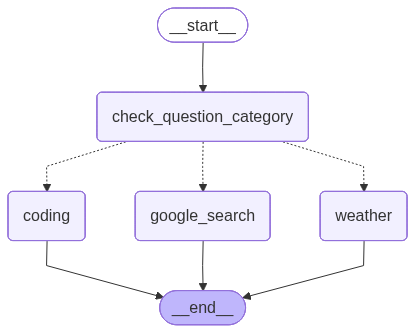

In [70]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())



In [71]:
response=graph.invoke({"question":"What is the capital of India?"})

BadRequestError: Error code: 400 - {'error': {'message': 'Tool choice is required, but model did not call a tool', 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': 'google_search'}}